# Title / Objective

# ============================================================
# 07 - Infrastructure Analytics
# Health Budget ML Project
# ============================================================

"""
Objective:
1. Analyze state-wise healthcare infrastructure.
2. Analyze PHCs, SHCs, District Hospitals and beds.
3. Examine missingness and data coverage.
4. Compare infrastructure across states.
5. Create a transparent prototype infrastructure priority/gap score.
6. Save processed analytics and reports.

Important:
This notebook is an academic prototype.
The available infrastructure data has limited year coverage and
different measures are not consistently reported in the same year.
Therefore, this notebook does NOT perform future forecasting.
"""

# Imports and paths

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

notebook_directory = Path.cwd().resolve()
project_root = (notebook_directory / "..").resolve()

infrastructure_path = project_root / "data" / "cleaned" / "infrastructure_state_year.csv"
processed_directory = (project_root / "data" / "processed").resolve()
graphs_directory = (project_root / "outputs" / "graphs").resolve()
reports_directory = (project_root / "outputs" / "reports").resolve()

processed_directory.mkdir(parents=True, exist_ok=True)
graphs_directory.mkdir(parents=True, exist_ok=True)
reports_directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Infrastructure input path: {infrastructure_path}")

Project root: C:\Users\bagad\health-budget-ml
Infrastructure input path: C:\Users\bagad\health-budget-ml\data\cleaned\infrastructure_state_year.csv


# Load dataset

In [3]:
infrastructure = pd.read_csv(infrastructure_path)

print(f"Infrastructure shape: {infrastructure.shape}")
print(f"Columns: {list(infrastructure.columns)}")
display(infrastructure.head())

Infrastructure shape: (74, 11)
Columns: ['State', 'Year', 'SHCs', 'PHCs', 'District_Hospitals', 'PHC_Beds', 'CHC_Beds', 'SDH_Beds', 'District_Hospital_Beds', 'Medical_College_Beds', 'Total_Beds']


,State,Year,SHCs,PHCs,District_Hospitals,PHC_Beds,CHC_Beds,SDH_Beds,District_Hospital_Beds,Medical_College_Beds,Total_Beds
0,All India/Total,2022-23,NaN,NaN,NaN,148729.0,180384.0,111557.0,153815.0,224176.0,818661.0
1,Andaman and Nicobar Islands,2021-22,124.0,27.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Andaman and Nicobar Islands,2022-23,NaN,NaN,NaN,230.0,210.0,NaN,220.0,700.0,1360.0
3,Andhra Pradesh,2021-22,11480.0,1689.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Andhra Pradesh,2022-23,NaN,NaN,NaN,8712.0,6400.0,5400.0,2600.0,12583.0,35695.0


# Source Structure and Coverage

In [4]:
print("Rows:", len(infrastructure))
print("Columns:", infrastructure.shape[1])
print("Unique state labels:", infrastructure["State"].nunique())
print("Year values:", infrastructure["Year"].dropna().unique().tolist())

print("\nData types:")
display(infrastructure.dtypes.to_frame("dtype"))

print("\nExact duplicate rows:", int(infrastructure.duplicated().sum()))

state_year_duplicates = infrastructure.duplicated(
    subset=["State", "Year"], keep=False
).sum()
print("Rows in duplicate State-Year combinations:", int(state_year_duplicates))

Rows: 74
Columns: 11
Unique state labels: 38
Year values: ['2022-23', '2021-22']

Data types:


,dtype
State,str
Year,str
SHCs,float64
PHCs,float64
District_Hospitals,float64
PHC_Beds,float64
CHC_Beds,float64
SDH_Beds,float64
District_Hospital_Beds,float64
Medical_College_Beds,float64



Exact duplicate rows: 0
Rows in duplicate State-Year combinations: 0


# Missingness Analysis

In [5]:
missing_summary = pd.DataFrame({
    "Column": infrastructure.columns,
    "Missing_Count": [int(infrastructure[col].isna().sum()) for col in infrastructure.columns],
    "Missing_Percentage": [round(infrastructure[col].isna().mean() * 100, 2) for col in infrastructure.columns]
})

display(missing_summary)

total_missing = int(infrastructure.isna().sum().sum())
total_cells = infrastructure.shape[0] * infrastructure.shape[1]
overall_missing_pct = round(total_missing / total_cells * 100, 2)

print(f"Total missing cells: {total_missing}")
print(f"Overall missing percentage: {overall_missing_pct}%")


,Column,Missing_Count,Missing_Percentage
0,State,0,0.00
1,Year,0,0.00
2,SHCs,37,50.00
3,PHCs,37,50.00
4,District_Hospitals,37,50.00
5,PHC_Beds,37,50.00
6,CHC_Beds,38,51.35
7,SDH_Beds,45,60.81
8,District_Hospital_Beds,37,50.00
9,Medical_College_Beds,41,55.41


Total missing cells: 346
Overall missing percentage: 42.51%


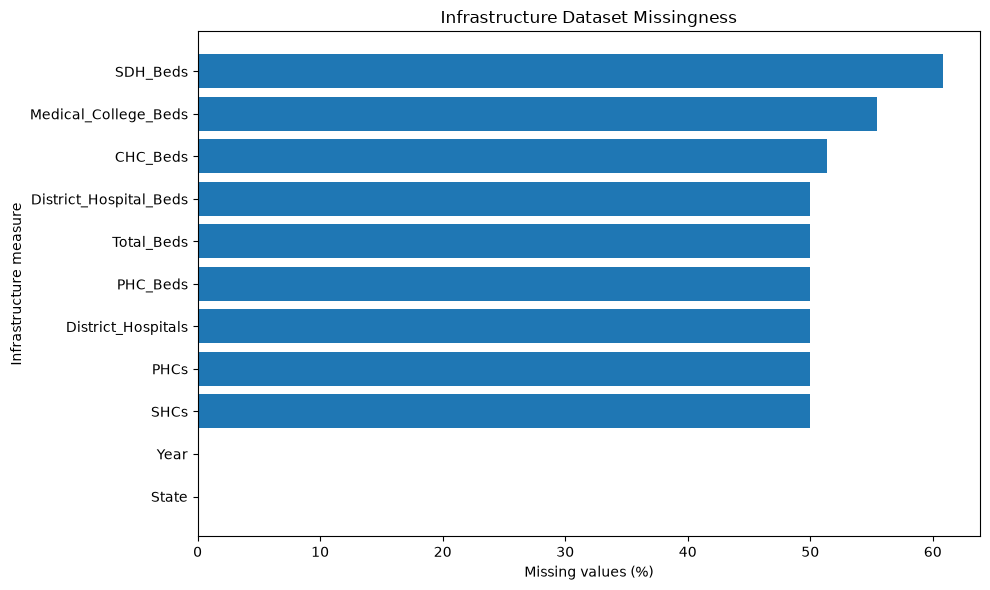

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\infrastructure_missingness.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = missing_summary.sort_values("Missing_Percentage")

ax.barh(plot_data["Column"], plot_data["Missing_Percentage"])
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Infrastructure measure")
ax.set_title("Infrastructure Dataset Missingness")

fig.tight_layout()
missing_plot_path = graphs_directory / "infrastructure_missingness.png"
fig.savefig(missing_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved chart to {missing_plot_path}")

# 5. Infrastructure Measures

In [7]:
infrastructure_columns = [
    "SHCs", "PHCs", "District_Hospitals",
    "PHC_Beds", "CHC_Beds", "SDH_Beds",
    "District_Hospital_Beds", "Medical_College_Beds", "Total_Beds"
]

missing_expected = [c for c in infrastructure_columns if c not in infrastructure.columns]
assert not missing_expected, f"Expected columns missing: {missing_expected}"

print("Infrastructure measures:")
print(infrastructure_columns)
display(infrastructure[infrastructure_columns].describe().T)

Infrastructure measures:
['SHCs', 'PHCs', 'District_Hospitals', 'PHC_Beds', 'CHC_Beds', 'SDH_Beds', 'District_Hospital_Beds', 'Medical_College_Beds', 'Total_Beds']


,count,mean,std,min,25%,50%,75%,max
SHCs,37.0,8747.513514,26343.438526,0.0,367.00,2653.0,9132.00,161829.0
PHCs,37.0,1678.540541,5044.267520,4.0,95.00,570.0,1572.00,31053.0
District_Hospitals,37.0,41.459459,125.775725,1.0,7.00,17.0,25.00,767.0
PHC_Beds,37.0,8039.405405,24279.922676,12.0,397.00,1688.0,7640.00,148729.0
CHC_Beds,36.0,10021.333333,29901.437000,28.0,303.75,3199.5,7054.25,180384.0
SDH_Beds,29.0,7693.586207,20654.042111,10.0,431.00,2035.0,5400.00,111557.0
District_Hospital_Beds,37.0,8314.324324,25093.947031,50.0,1017.00,2600.0,6174.00,153815.0
Medical_College_Beds,33.0,14101.515152,38441.902619,350.0,1850.00,5420.0,12583.00,224176.0
Total_Beds,37.0,44251.945946,132982.250741,250.0,2795.00,14150.0,42733.00,818661.0


# Year-wise Coverage

In [8]:
year_coverage = (
    infrastructure.groupby("Year")
    .agg(Rows=("State", "size"), States=("State", "nunique"))
    .reset_index()
)
display(year_coverage)

year_measure_coverage = pd.DataFrame({
    "Measure": infrastructure_columns,
    "2021-22_nonmissing": [
        int(infrastructure.loc[infrastructure["Year"] == "2021-22", c].notna().sum())
        for c in infrastructure_columns
    ],
    "2022-23_nonmissing": [
        int(infrastructure.loc[infrastructure["Year"] == "2022-23", c].notna().sum())
        for c in infrastructure_columns
    ]
})
display(year_measure_coverage)

,Year,Rows,States
0,2021-22,37,37
1,2022-23,37,37


,Measure,2021-22_nonmissing,2022-23_nonmissing
0,SHCs,37,0
1,PHCs,37,0
2,District_Hospitals,37,0
3,PHC_Beds,0,37
4,CHC_Beds,0,36
5,SDH_Beds,0,29
6,District_Hospital_Beds,0,37
7,Medical_College_Beds,0,33
8,Total_Beds,0,37


# State-wise Infrastructure Summary

In [9]:
state_summary = (
    infrastructure.groupby("State")[infrastructure_columns]
    .sum(min_count=1)
    .reset_index()
)
display(state_summary.head(15))

,State,SHCs,PHCs,District_Hospitals,PHC_Beds,CHC_Beds,SDH_Beds,District_Hospital_Beds,Medical_College_Beds,Total_Beds
0,All India/Total,NaN,NaN,NaN,148729.0,180384.0,111557.0,153815.0,224176.0,818661.0
1,Andaman and Nicobar Islands,124.0,27.0,2.0,230.0,210.0,NaN,220.0,700.0,1360.0
2,Andhra Pradesh,11480.0,1689.0,17.0,8712.0,6400.0,5400.0,2600.0,12583.0,35695.0
3,Arunachal Pradesh,367.0,131.0,19.0,397.0,594.0,NaN,1151.0,350.0,2492.0
4,Assam,4701.0,1010.0,25.0,3166.0,6218.0,844.0,3677.0,9343.0,23248.0
5,Bihar,10399.0,1760.0,36.0,5596.0,8039.0,2459.0,4575.0,7251.0,27920.0
6,Chandigarh,0.0,43.0,1.0,23.0,120.0,100.0,527.0,3096.0,3866.0
7,Chhattisgarh,5494.0,822.0,27.0,5015.0,6726.0,629.0,3542.0,4458.0,20370.0
8,Dadra and Nagar Haveli and Daman and Diu,97.0,14.0,2.0,177.0,132.0,100.0,240.0,589.0,1238.0
9,Delhi,14.0,550.0,40.0,12.0,NaN,431.0,9789.0,12060.0,22292.0


# State Comparison by Infrastructure Measure

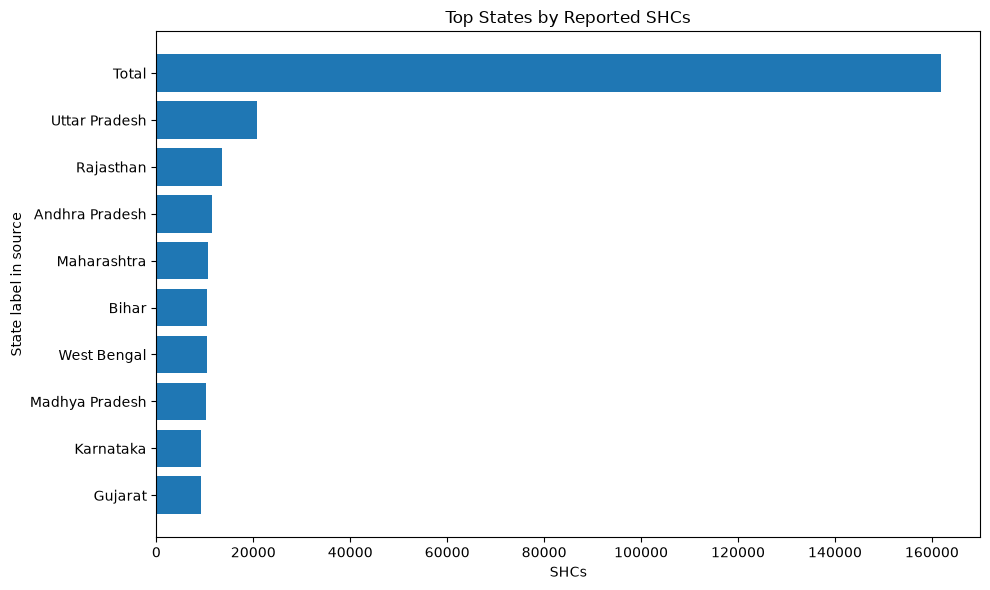

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\infrastructure_shcs.png


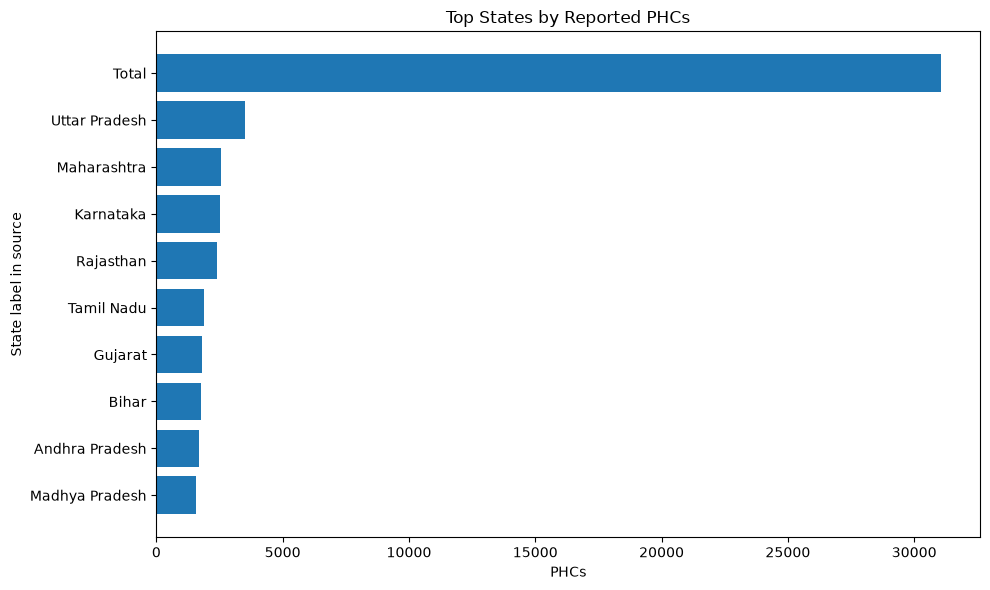

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\infrastructure_phcs.png


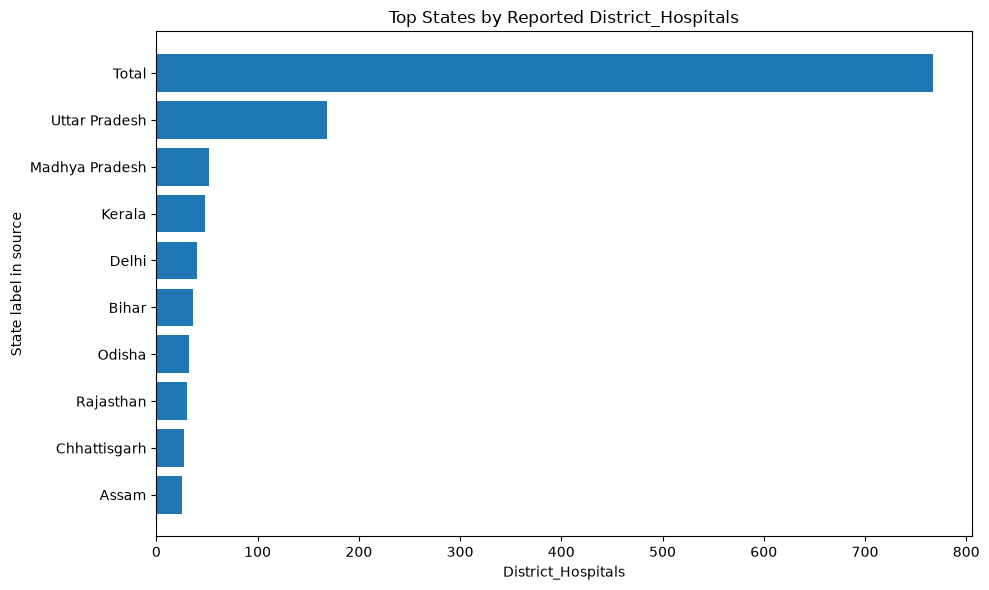

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\infrastructure_district_hospitals.png


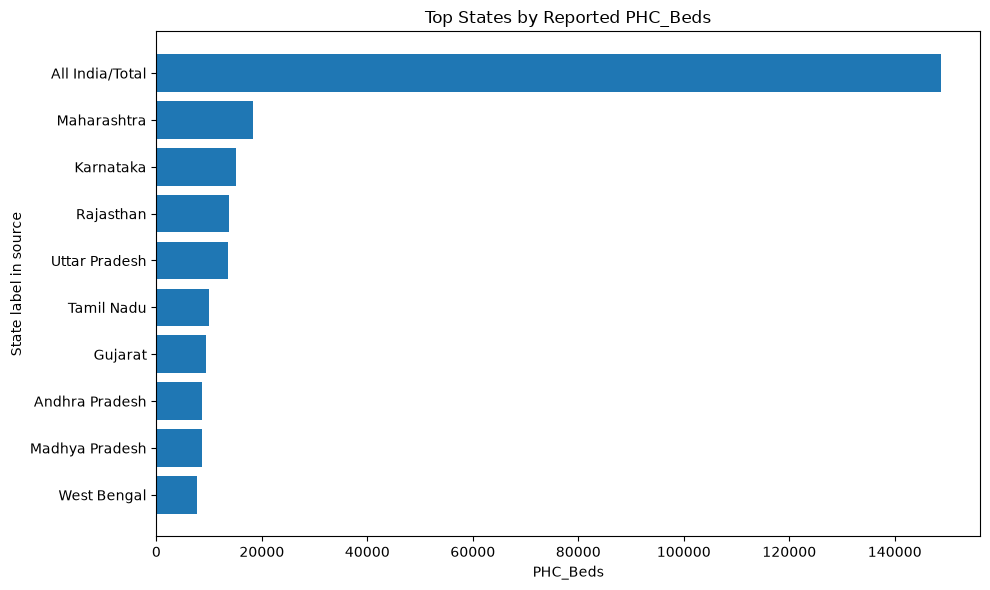

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\infrastructure_phc_beds.png


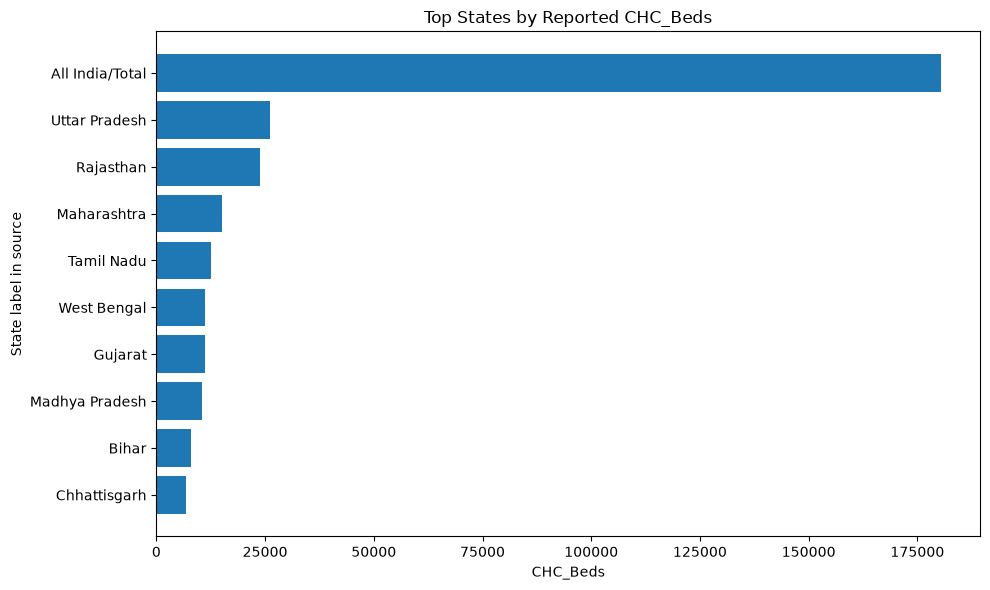

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\infrastructure_chc_beds.png


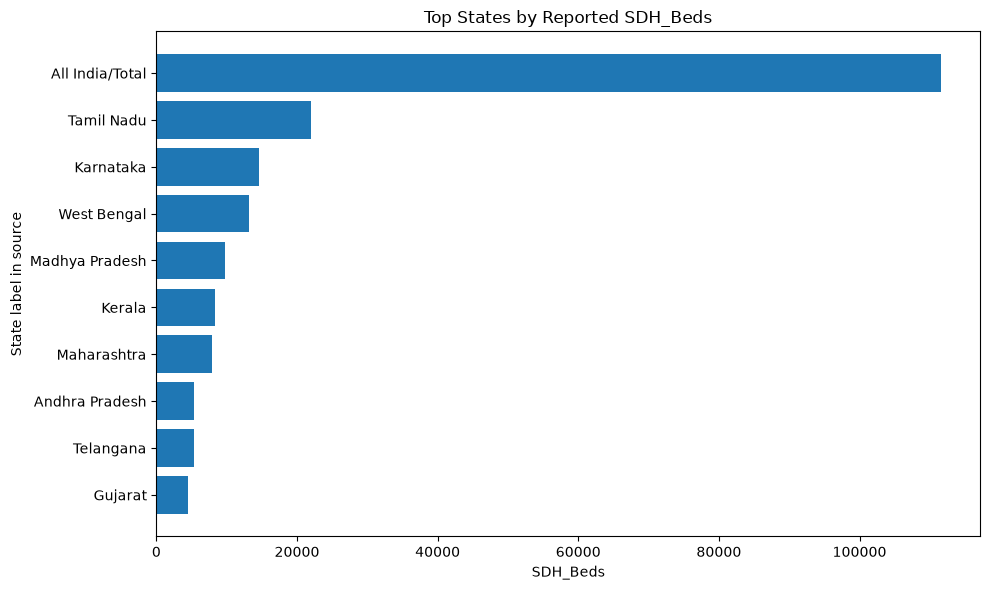

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\infrastructure_sdh_beds.png


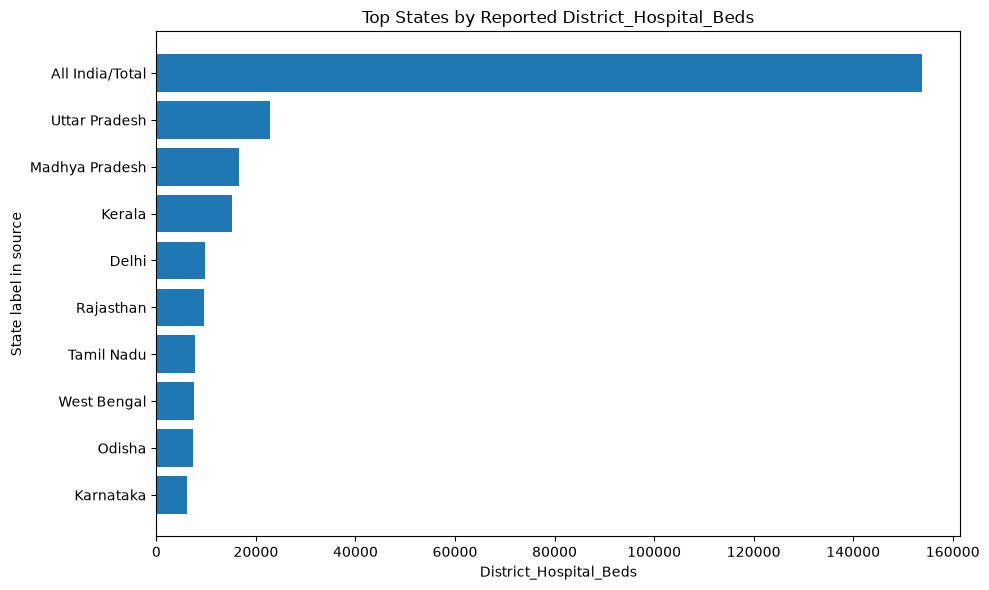

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\infrastructure_district_hospital_beds.png


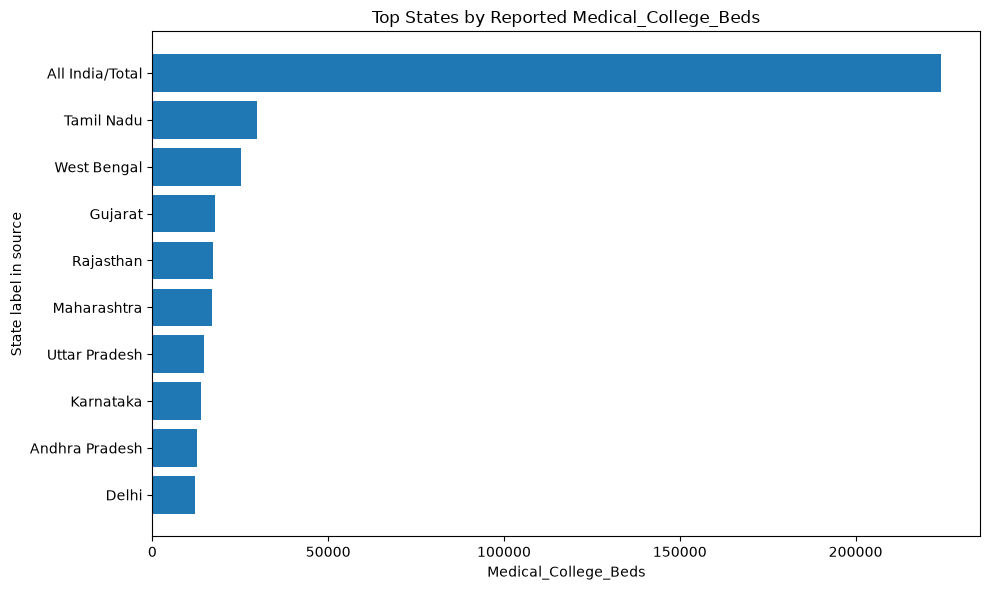

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\infrastructure_medical_college_beds.png


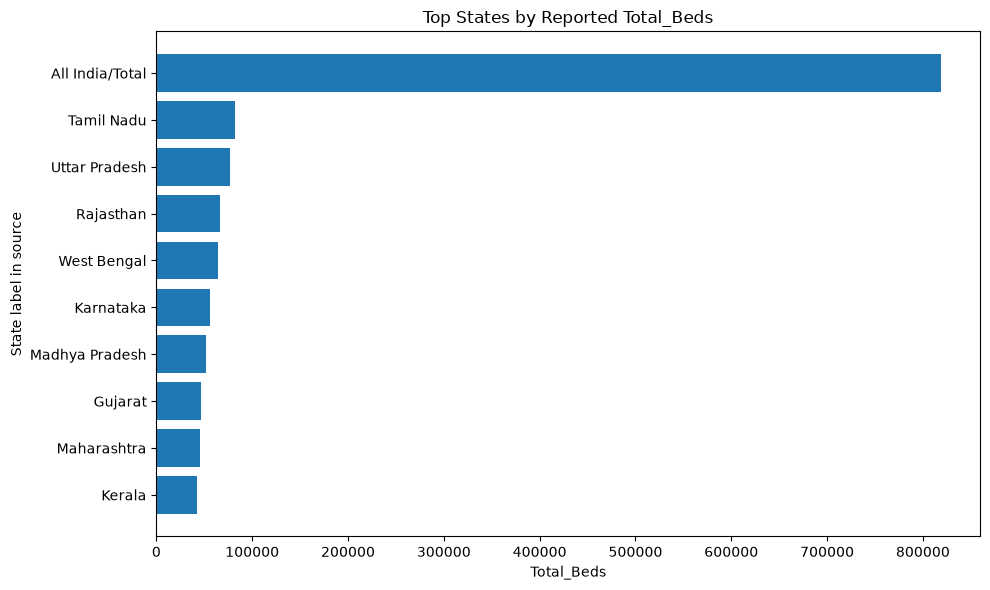

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\infrastructure_total_beds.png


In [10]:
for column in infrastructure_columns:
    available = (
        infrastructure.groupby("State")[column]
        .sum(min_count=1)
        .dropna()
        .sort_values(ascending=False)
        .head(10)
    )
    if available.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(available.index[::-1], available.values[::-1])
    ax.set_xlabel(column)
    ax.set_ylabel("State label in source")
    ax.set_title(f"Top States by Reported {column}")
    fig.tight_layout()

    safe_name = column.lower().replace(" ", "_").replace("/", "_")
    output_path = graphs_directory / f"infrastructure_{safe_name}.png"
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved chart to {output_path}")

# Measure Coverage by State

In [11]:
state_measure_coverage = (
    infrastructure.groupby("State")[infrastructure_columns]
    .apply(lambda frame: frame.notna().any())
)
display(state_measure_coverage)

,SHCs,PHCs,District_Hospitals,PHC_Beds,CHC_Beds,SDH_Beds,District_Hospital_Beds,Medical_College_Beds,Total_Beds
State,,,,,,,,,
All India/Total,False,False,False,True,True,True,True,True,True
Andaman and Nicobar Islands,True,True,True,True,True,False,True,True,True
Andhra Pradesh,True,True,True,True,True,True,True,True,True
Arunachal Pradesh,True,True,True,True,True,False,True,True,True
Assam,True,True,True,True,True,True,True,True,True
Bihar,True,True,True,True,True,True,True,True,True
Chandigarh,True,True,True,True,True,True,True,True,True
Chhattisgarh,True,True,True,True,True,True,True,True,True
Dadra and Nagar Haveli and Daman and Diu,True,True,True,True,True,True,True,True,True


# Prototype Infrastructure Gap Score

Create a demonstration score from the available infrastructure observations.
For each measure, values are min-max normalized across the source observations. The prototype combines:
- an availability component from observed normalized infrastructure values;
- a missingness component.
This is a demonstration score only. It is not an official government requirement, clinically validated measure, or population-adjusted infrastructure-need score. Missing values remain missing.

In [12]:
score_data = infrastructure.copy()

normalized_columns = []
missing_indicator_columns = []

for column in infrastructure_columns:
    values = score_data[column]

    if values.notna().sum() > 0 and values.dropna().nunique() > 1:
        normalized = (values - values.min(skipna=True)) / (
            values.max(skipna=True) - values.min(skipna=True)
        )
    else:
        normalized = pd.Series(np.nan, index=score_data.index)

    normalized_column = f"{column}_Normalized"
    missing_column = f"{column}_Missing"

    score_data[normalized_column] = normalized
    score_data[missing_column] = values.isna().astype(int)

    normalized_columns.append(normalized_column)
    missing_indicator_columns.append(missing_column)

score_data["Infrastructure_Availability_Score"] = (
    score_data[normalized_columns].mean(axis=1, skipna=True)
)

score_data["Infrastructure_Missingness_Rate"] = (
    score_data[missing_indicator_columns].mean(axis=1)
)

score_data["Prototype_Infrastructure_Gap_Score"] = (
    0.7 * (1 - score_data["Infrastructure_Availability_Score"])
    + 0.3 * score_data["Infrastructure_Missingness_Rate"]
)

no_observed_measure = score_data[infrastructure_columns].notna().sum(axis=1).eq(0)

score_data.loc[
    no_observed_measure,
    ["Infrastructure_Availability_Score", "Prototype_Infrastructure_Gap_Score"]
] = np.nan

display(score_data[
    ["State", "Year", "Infrastructure_Availability_Score",
     "Infrastructure_Missingness_Rate", "Prototype_Infrastructure_Gap_Score"]
].head(15))

,State,Year,Infrastructure_Availability_Score,Infrastructure_Missingness_Rate,Prototype_Infrastructure_Gap_Score
0,All India/Total,2022-23,1.000000,0.333333,0.100000
1,Andaman and Nicobar Islands,2021-22,0.000937,0.666667,0.899344
2,Andaman and Nicobar Islands,2022-23,0.001300,0.444444,0.832423
3,Andhra Pradesh,2021-22,0.048699,0.666667,0.865911
4,Andhra Pradesh,2022-23,0.042783,0.333333,0.770052
5,Arunachal Pradesh,2021-22,0.009952,0.666667,0.893033
6,Arunachal Pradesh,2022-23,0.003125,0.444444,0.831146
7,Assam,2021-22,0.030927,0.666667,0.878351
8,Assam,2022-23,0.025812,0.333333,0.781931
9,Bihar,2021-22,0.055502,0.666667,0.861148


# State-level Prototype Gap Analysis

In [13]:
state_priority_summary = (
    score_data.groupby("State")
    .agg(
        Observed_Years=("Year", "nunique"),
        Infrastructure_Availability_Score=("Infrastructure_Availability_Score", "mean"),
        Infrastructure_Missingness_Rate=("Infrastructure_Missingness_Rate", "mean"),
        Prototype_Infrastructure_Gap_Score=("Prototype_Infrastructure_Gap_Score", "mean")
    )
    .reset_index()
    .sort_values("Prototype_Infrastructure_Gap_Score", ascending=False, na_position="last")
)

print("State-level prototype infrastructure gap summary (not an official ranking):")
display(state_priority_summary.head(15))

State-level prototype infrastructure gap summary (not an official ranking):


,State,Observed_Years,Infrastructure_Availability_Score,Infrastructure_Missingness_Rate,Prototype_Infrastructure_Gap_Score
18,Ladakh,2,0.001397,0.611111,0.882355
30,Sikkim,2,0.001485,0.611111,0.882294
25,Nagaland,2,0.005417,0.611111,0.879541
19,Lakshadweep,2,0.000116,0.555556,0.866585
1,Andaman and Nicobar Islands,2,0.001119,0.555556,0.865884
27,Puducherry,2,0.003930,0.555556,0.863915
3,Arunachal Pradesh,2,0.006539,0.555556,0.862089
14,Jammu and Kashmir,2,0.020088,0.555556,0.852605
8,Dadra and Nagar Haveli and Daman and Diu,2,0.000871,0.500000,0.849390
10,Goa,2,0.001839,0.500000,0.848713


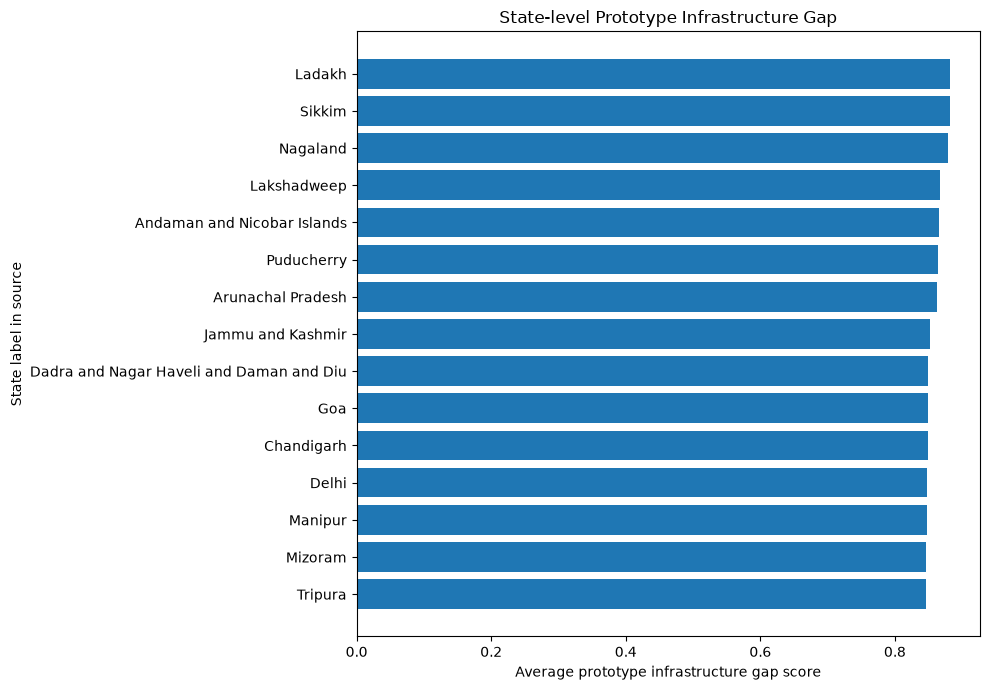

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\infrastructure_state_prototype_gap.png


In [14]:
plot_data = state_priority_summary.dropna(
    subset=["Prototype_Infrastructure_Gap_Score"]
).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    plot_data["State"][::-1],
    plot_data["Prototype_Infrastructure_Gap_Score"][::-1]
)
ax.set_xlabel("Average prototype infrastructure gap score")
ax.set_ylabel("State label in source")
ax.set_title("State-level Prototype Infrastructure Gap")
fig.tight_layout()

state_priority_plot_path = graphs_directory / "infrastructure_state_prototype_gap.png"
fig.savefig(state_priority_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved chart to {state_priority_plot_path}")

# Save Processed Infrastructure Analytics

In [15]:
analytics_columns = list(infrastructure.columns) + [
    "Infrastructure_Availability_Score",
    "Infrastructure_Missingness_Rate",
    "Prototype_Infrastructure_Gap_Score"
]

infrastructure_analytics = score_data[analytics_columns].copy()

processed_infrastructure_path = (
    processed_directory / "infrastructure_health_analytics.csv"
)

infrastructure_analytics.to_csv(processed_infrastructure_path, index=False)

print(f"Saved processed analytics: {processed_infrastructure_path}")
print(f"Rows saved: {len(infrastructure_analytics)}; source rows: {len(infrastructure)}")
print(f"Columns saved: {list(infrastructure_analytics.columns)}")

assert len(infrastructure_analytics) == len(infrastructure)
assert infrastructure_analytics["State"].equals(infrastructure["State"])
assert infrastructure_analytics["Year"].equals(infrastructure["Year"])

Saved processed analytics: C:\Users\bagad\health-budget-ml\data\processed\infrastructure_health_analytics.csv
Rows saved: 74; source rows: 74
Columns saved: ['State', 'Year', 'SHCs', 'PHCs', 'District_Hospitals', 'PHC_Beds', 'CHC_Beds', 'SDH_Beds', 'District_Hospital_Beds', 'Medical_College_Beds', 'Total_Beds', 'Infrastructure_Availability_Score', 'Infrastructure_Missingness_Rate', 'Prototype_Infrastructure_Gap_Score']


# Generate Summary Report

In [16]:
score_available = int(
    infrastructure_analytics["Prototype_Infrastructure_Gap_Score"].notna().sum()
)
score_missing = int(
    infrastructure_analytics["Prototype_Infrastructure_Gap_Score"].isna().sum()
)

summary_report = pd.DataFrame([
    {"Metric": "Infrastructure rows", "Value": len(infrastructure),
     "Interpretation": "Rows in the cleaned state-year source."},
    {"Metric": "Infrastructure columns", "Value": infrastructure.shape[1],
     "Interpretation": "Columns in the cleaned source."},
    {"Metric": "Unique state labels", "Value": infrastructure["State"].nunique(),
     "Interpretation": "Distinct state labels in the source."},
    {"Metric": "Reporting years", "Value": ", ".join(map(str, infrastructure["Year"].dropna().unique())),
     "Interpretation": "Only years present in the source are reported."},
    {"Metric": "Exact duplicate rows", "Value": int(infrastructure.duplicated().sum()),
     "Interpretation": "Reported only; no rows removed."},
    {"Metric": "Total missing cells", "Value": total_missing,
     "Interpretation": "Missing infrastructure values remain missing."},
    {"Metric": "Overall missing percentage", "Value": overall_missing_pct,
     "Interpretation": "Missing cells divided by all source cells."},
    {"Metric": "Prototype score available rows", "Value": score_available,
     "Interpretation": "Rows with at least one observed infrastructure measure."},
    {"Metric": "Prototype score missing rows", "Value": score_missing,
     "Interpretation": "Rows with no observed infrastructure measure."},
    {"Metric": "Forecasting suitability", "Value": "Not suitable",
     "Interpretation": "Only two years and uneven measure coverage."},
    {"Metric": "Prototype score suitability", "Value": "Demonstration only",
     "Interpretation": "Not an official or clinically validated gap score."}
])

summary_report_path = reports_directory / "infrastructure_analytics_summary.csv"
summary_report.to_csv(summary_report_path, index=False)

print(f"Saved summary report to {summary_report_path}")
display(summary_report)

Saved summary report to C:\Users\bagad\health-budget-ml\outputs\reports\infrastructure_analytics_summary.csv


,Metric,Value,Interpretation
0,Infrastructure rows,74,Rows in the cleaned state-year source.
1,Infrastructure columns,11,Columns in the cleaned source.
2,Unique state labels,38,Distinct state labels in the source.
3,Reporting years,"2022-23, 2021-22",Only years present in the source are reported.
4,Exact duplicate rows,0,Reported only; no rows removed.
5,Total missing cells,346,Missing infrastructure values remain missing.
6,Overall missing percentage,42.51,Missing cells divided by all source cells.
7,Prototype score available rows,74,Rows with at least one observed infrastructure...
8,Prototype score missing rows,0,Rows with no observed infrastructure measure.
9,Forecasting suitability,Not suitable,Only two years and uneven measure coverage.
